In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

In [5]:
df = pd.read_csv('rawdata.csv')

print(df.head())

print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

## Data Cleaning

In [6]:
#Turned specific columns into numerical variable 
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})
print(df[['Attrition', 'OverTime', 'Gender']].head())

  Attrition OverTime Gender
0         1        1      0
1         0        0      1
2         1        1      1
3         0        1      0
4         0        0      1


In [7]:
#removing unecessary data
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=drop_cols)

In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 0


In [9]:
print(df.head())
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41         1      Travel_Rarely       1102                   Sales   
1   49         0  Travel_Frequently        279  Research & Development   
2   37         1      Travel_Rarely       1373  Research & Development   
3   33         0  Travel_Frequently       1392  Research & Development   
4   27         0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction Gender  \
0                 1          2  Life Sciences                        2      0   
1                 8          1  Life Sciences                        3      1   
2                 2          2          Other                        4      1   
3                 3          4  Life Sciences                        4      0   
4                 2          1        Medical                        1      1   

   ...  PerformanceRating  RelationshipSatisfaction  StockOptionLeve

In [10]:
# checking Class Imbalance
attrition_counts = df['Attrition'].value_counts()
attrition_pcts = df['Attrition'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    'Count': attrition_counts,
    'Percentage (%)': attrition_pcts.round(2)
})
print("\nAttrition:")
print(imbalance_summary)


Attrition:
           Count  Percentage (%)
Attrition                       
0           1233           83.88
1            237           16.12


In [11]:
print(" Attrition ανά Τμήμα ")
print((df.groupby('Department')['Attrition'].mean() * 100).sort_values(ascending=False).round(2))

print("\n Attrition ανά Ρόλο Εργασίας ")
print((df.groupby('JobRole')['Attrition'].mean() * 100).sort_values(ascending=False).round(2))

 Attrition ανά Τμήμα 
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: object

 Attrition ανά Ρόλο Εργασίας 
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist            16.1
Manufacturing Director         6.9
Healthcare Representative     6.87
Manager                        4.9
Research Director              2.5
Name: Attrition, dtype: object


In [12]:
focus_cats = ['Department', 'JobRole', 'JobLevel', 'EnvironmentSatisfaction', 'PerformanceRating']
for i in focus_cats:
    print(f"\n Attrition ανά {i} ")
    summary = df.groupby(i)['Attrition'].agg(
        Headcount='count', #πλήθος γραμμών
        Attrition_Count='sum', #πόσοι έφυγαν
        Attrition_Rate=lambda x: (x.mean() * 100).round(2) #ποσοστό αποχώρησης
    ).reset_index()
    print(summary.sort_values(by='Attrition_Rate', ascending=False).to_string(index=False))


 Attrition ανά Department 
            Department  Headcount Attrition_Count  Attrition_Rate
                 Sales        446              92           20.63
       Human Resources         63              12           19.05
Research & Development        961             133           13.84

 Attrition ανά JobRole 
                  JobRole  Headcount Attrition_Count  Attrition_Rate
     Sales Representative         83              33           39.76
    Laboratory Technician        259              62           23.94
          Human Resources         52              12           23.08
          Sales Executive        326              57           17.48
       Research Scientist        292              47           16.10
   Manufacturing Director        145              10            6.90
Healthcare Representative        131               9            6.87
                  Manager        102               5            4.90
        Research Director         80               2          

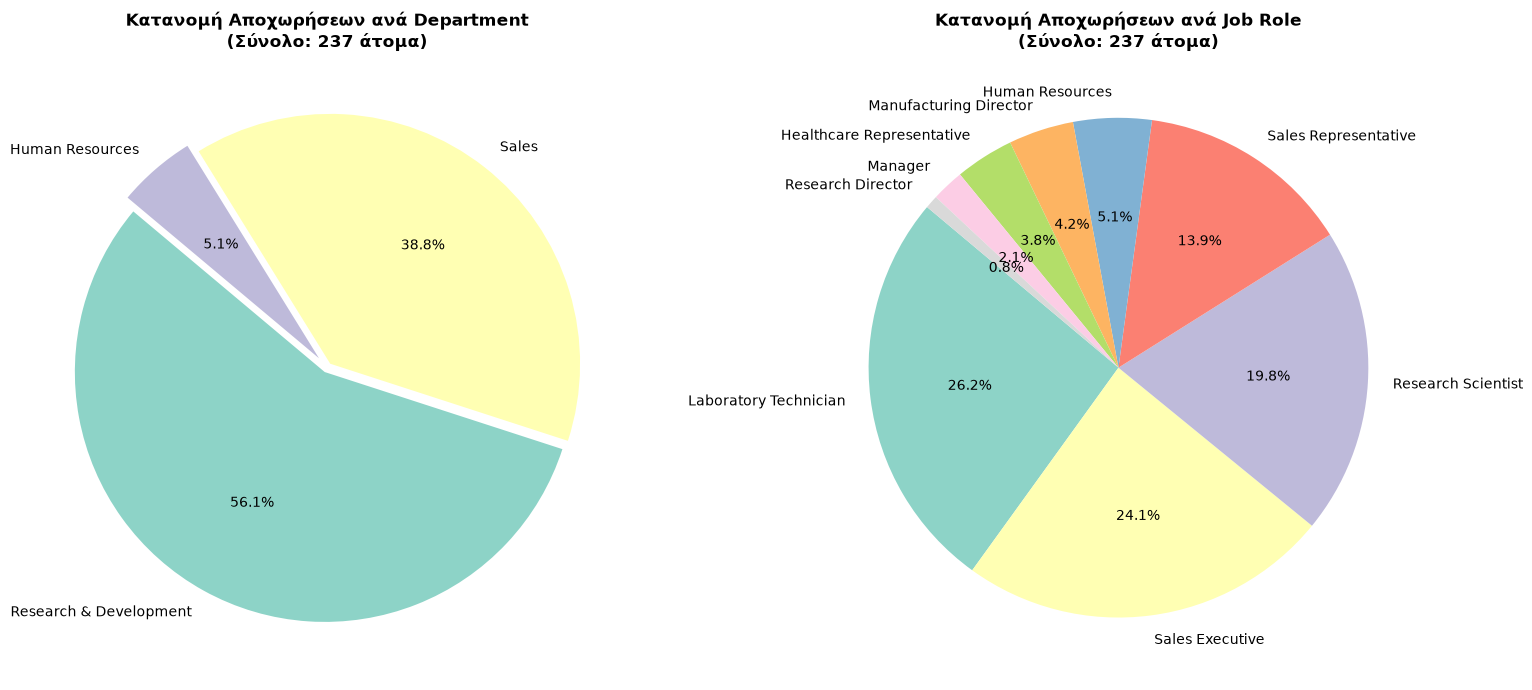

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.get_cmap('Set3')

dept_attr = df[df['Attrition'] == 1]['Department'].value_counts()
dept_colors = [cmap(i) for i in range(len(dept_attr))]

axes[0].pie(
    dept_attr, 
    labels=dept_attr.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=dept_colors,
    explode=[0.02, 0.02, 0.05]
)
axes[0].set_title('Κατανομή Αποχωρήσεων ανά Department\n(Σύνολο: 237 άτομα)', fontsize=12, fontweight='bold')

role_attr = df[df['Attrition'] == 1]['JobRole'].value_counts()
role_colors = [cmap(i % 12) for i in range(len(role_attr))]  

axes[1].pie(
    role_attr, 
    labels=role_attr.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=role_colors
)
axes[1].set_title('Κατανομή Αποχωρήσεων ανά Job Role\n(Σύνολο: 237 άτομα)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# 1. PerformanceRating & OverTime
print("Attrition Rate ανά Performance & OverTime ---")
cross_perf = df.groupby(['PerformanceRating', 'OverTime'])['Attrition'].agg(
    Headcount='count',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2)
).reset_index()
print(cross_perf.to_string(index=False))

print("\n Attrition Rate ανά JobInvolvement ")
cross_involv = df.groupby('JobInvolvement')['Attrition'].agg(
    Headcount='count',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2)
).reset_index()
print(cross_involv.to_string(index=False))

Attrition Rate ανά Performance & OverTime ---
 PerformanceRating  OverTime  Headcount  Attrition_Rate
                 3         0        893           10.75
                 3         1        351           29.63
                 4         0        161            8.70
                 4         1         65           35.38

 Attrition Rate ανά JobInvolvement 
 JobInvolvement  Headcount  Attrition_Rate
              1         83           33.73
              2        375           18.93
              3        868           14.40
              4        144            9.03


### Συμπεράσματα

#### Performance & OverTime
* **Κίνδυνος Burnout στα Κορυφαία Στελέχη:** Το απλό `PerformanceRating` από μόνο του δεν δείχνει διαφορά στην αποχώρηση (16%), αλλά σε συνδυασμό με τις υπερωρίες αλλάζει δραματικά:
  * Στους υπαλλήλους με **υψηλή απόδοση (Rating 4)** που **κάνουν υπερωρίες (OverTime = 1)**, το ποσοστό φυγής εκτοξεύεται στο **35.38%**, **8.70%** όσων δεν κάνουν υπερωρίες (αύξηση X4).
  * Αντίστοιχα, στο **Rating 3**, οι υπερωρίες τριπλασιάζουν την πιθανότητα αποχώρησης από **10.75%** σε **29.63%**.
* **Συμπέρασμα:** Η εταιρεία χάνει τα πιο παραγωγικά της στελέχη κυρίως λόγω εξουθένωσης από υπερωρίες.

#### 2. Βαθμός Εμπλοκής στην Εργασία (Job Involvement)
* **Αντιστρόφως Ανάλογη Σχέση:** Όσο μειώνεται το ενδιαφέρον/δέσμευση του εργαζομένου για τη δουλειά του, τόσο αυξάνεται ραγδαία η αποχώρηση:
  * **Επίπεδο 1 (Πολύ χαμηλή εμπλοκή):** Αποχωρεί το **33.73%** (1 στους 3).
  * **Επίπεδο 2 (Μέτρια εμπλοκή):** Αποχωρεί το **18.93%**.
  * **Επίπεδο 3 (Υψηλή εμπλοκή):** Αποχωρεί το **14.40%**.
  * **Επίπεδο 4 (Πολύ υψηλή εμπλοκή):** Αποχωρεί μόλις το **9.03%**.
* **Συμπέρασμα:** Η έλλειψη κινήτρων και εμπλοκής στα πρώιμα στάδια αποτελεί το πιο αξιόπιστο καμπανάκι κινδύνου για μελλοντική παραίτηση.

C:\Users\Konst\AppData\Local\Temp\ipykernel_6624\4072467900.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


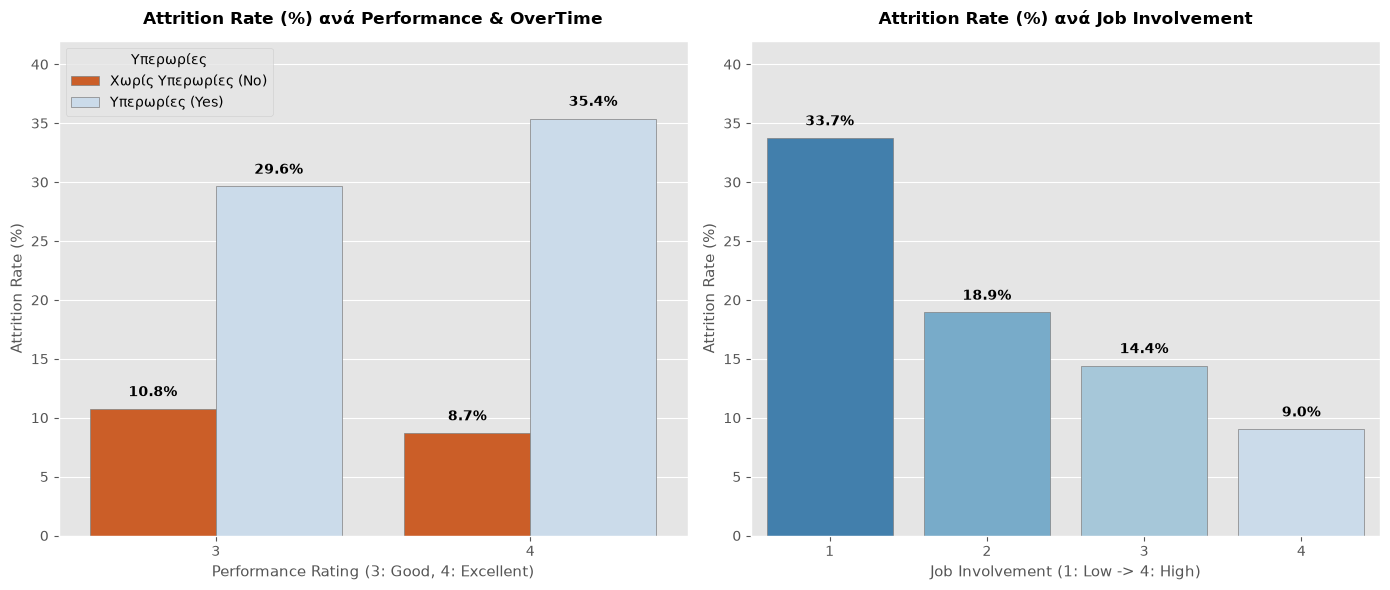

In [15]:
plt.style.use('ggplot')
cmap2 = plt.get_cmap('tab20c')
set3_colors = [cmap2(i) for i in range(12)]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

perf_ot = df.groupby(['PerformanceRating', 'OverTime'])['Attrition'].mean().reset_index()
perf_ot['Attrition_Rate'] = perf_ot['Attrition'] * 100
perf_ot['OverTime_Label'] = perf_ot['OverTime'].map({1: 'Υπερωρίες (Yes)', 0: 'Χωρίς Υπερωρίες (No)'})

sns.barplot(
    ax=axes[0],
    data=perf_ot,
    x='PerformanceRating',
    y='Attrition_Rate',
    hue='OverTime_Label',
    palette=[set3_colors[4], set3_colors[3]],
    edgecolor='gray'
)
axes[0].set_title('Attrition Rate (%) ανά Performance & OverTime', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Performance Rating (3: Good, 4: Excellent)', fontsize=11)
axes[0].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[0].set_ylim(0, 42)
axes[0].legend(title='Υπερωρίες')

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height + 0.8),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

job_inv = df.groupby('JobInvolvement')['Attrition'].mean().reset_index()
job_inv['Attrition_Rate'] = job_inv['Attrition'] * 100

sns.barplot(
    ax=axes[1],
    data=job_inv,
    x='JobInvolvement',
    y='Attrition_Rate',
    palette=[set3_colors[i] for i in range(4)],
    edgecolor='gray'
)
axes[1].set_title('Attrition Rate (%) ανά Job Involvement', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Job Involvement (1: Low -> 4: High)', fontsize=11)
axes[1].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[1].set_ylim(0, 42)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height + 0.8),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

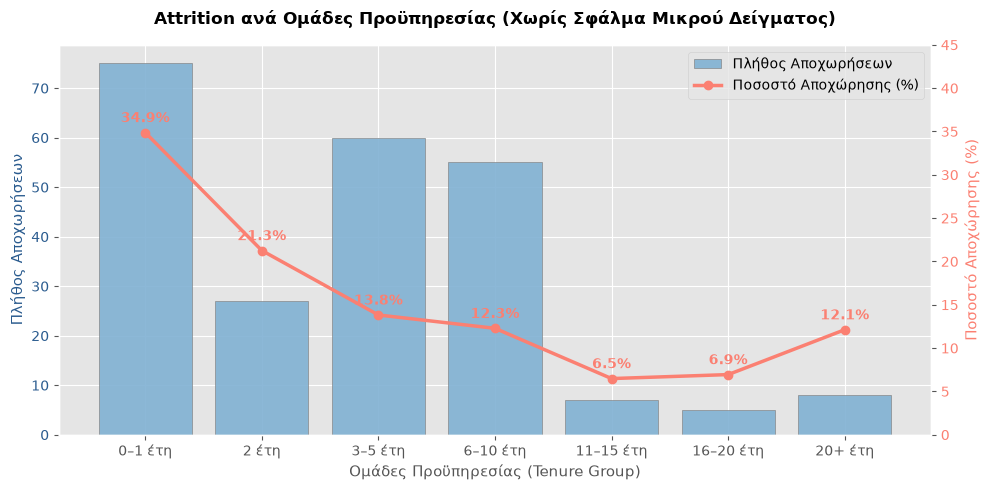

In [16]:
bins = [0, 1, 2, 5, 10, 15, 20, 45]
labels = ['0–1 έτη', '2 έτη', '3–5 έτη', '6–10 έτη', '11–15 έτη', '16–20 έτη', '20+ έτη']
df['Tenure_Group'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels, include_lowest=True, right=True)

binned = df.groupby('Tenure_Group', observed=True)['Attrition'].agg(
    Headcount='count',
    Attritions='sum',
    Attrition_Rate=lambda x: (x.mean() * 100).round(2) # Ανώνυμη συνάρτηση για μετατροπή του μέσου όρου (0/1)
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(binned['Tenure_Group'], binned['Attritions'], color=cmap(4), edgecolor='gray', alpha=0.9, label='Πλήθος Αποχωρήσεων')
ax1.set_xlabel('Ομάδες Προϋπηρεσίας (Tenure Group)', fontsize=11)
ax1.set_ylabel('Πλήθος Αποχωρήσεων', fontsize=11, color='#2b5c8f')
ax1.tick_params(axis='y', labelcolor='#2b5c8f')

ax2 = ax1.twinx()
ax2.plot(binned['Tenure_Group'], binned['Attrition_Rate'], color=cmap(3), marker='o', linewidth=2.5, label='Ποσοστό Αποχώρησης (%)')
ax2.set_ylabel('Ποσοστό Αποχώρησης (%)', fontsize=11, color=cmap(3))
ax2.tick_params(axis='y', labelcolor=cmap(3))
ax2.set_ylim(0, 45)
ax2.grid(False)

for i, txt in enumerate(binned['Attrition_Rate']):
    ax2.annotate(f'{txt:.1f}%', (i, txt + 1.2), ha='center', fontsize=10, fontweight='bold', color=cmap(3))

plt.title('Attrition ανά Ομάδες Προϋπηρεσίας (Χωρίς Σφάλμα Μικρού Δείγματος)', fontsize=12, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

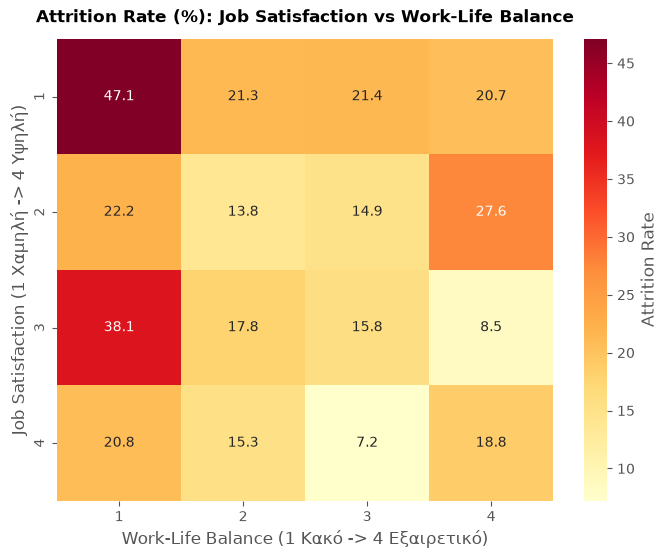

In [17]:
pivot_sat_wlb = df.pivot_table(
    index='JobSatisfaction', 
    columns='WorkLifeBalance', 
    values='Attrition', 
    aggfunc=lambda x: (x.mean() * 100).round(1)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_sat_wlb, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Attrition Rate'}
)
plt.title('Attrition Rate (%): Job Satisfaction vs Work-Life Balance', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Work-Life Balance (1 Κακό -> 4 Εξαιρετικό)')
plt.ylabel('Job Satisfaction (1 Χαμηλή -> 4 Υψηλή)')
plt.show()

## Machine Learning

In [18]:
print("Dtype:", df['Attrition'].dtype)

print("\nUnique values:", df['Attrition'].unique())

non_binary = df[~df['Attrition'].isin([0, 1])]['Attrition']
print(f"\nΠλήθος τιμών που δεν είναι 0/1: {len(non_binary)}")
print(non_binary.value_counts(dropna=False))

df['Attrition'] = df['Attrition'].astype(int)

Dtype: object

Unique values: [1 0]

Πλήθος τιμών που δεν είναι 0/1: 0
Series([], Name: count, dtype: int64)


In [19]:
# One-Hot Encoding
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded = df_encoded.drop(columns=['Tenure_Group'])

# Διαχωρισμός σε X Features και y Target
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Train / Test Split stratify=y λόγω του class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=6, 
    class_weight='balanced',  # Τιμωρεί X5 αυστηρότερα το λάθος στις αποχωρήσεις λόγω class imbalance 
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # πιθανότητα αποχώρησης για κάθε υπάλληλο του test set
y_pred = (y_pred_proba >= 0.5).astype(int) # Μετατρέπει την πιθανότητα σε τελική απόφαση με όριο το 50%.

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print("\nTop 10 Παράγοντες Επιρροής:\n", importance)

df_bi = df.copy()
df_bi['Attrition_Risk_Score'] = rf_model.predict_proba(X)[:, 1].round(4)
df_bi['Risk_Category'] = pd.cut(
    df_bi['Attrition_Risk_Score'], 
    bins=[-0.1, 0.35, 0.60, 1.0], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_bi.to_csv('hr_attrition_dashboard_data.csv', index=False)

ROC-AUC Score: 0.7753

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       247
           1       0.45      0.55      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.69       294
weighted avg       0.84      0.82      0.83       294


Top 10 Παράγοντες Επιρροής:
 TotalWorkingYears       0.078976
MonthlyIncome           0.076010
OverTime                0.073076
Age                     0.060618
YearsAtCompany          0.055384
YearsWithCurrManager    0.053935
StockOptionLevel        0.047018
JobLevel                0.043450
DailyRate               0.038076
DistanceFromHome        0.033294
dtype: float64


### Αξιολόγηση Μοντέλου Πρόβλεψης Κινδύνου Random Forest

#### 1. Μετρικές Απόδοσης Μοντέλου
* **ROC-AUC Score (0.7753):** Το μοντέλο διαθέτει καλή διακριτική ικανότητα, ξεχωρίζοντας με αξιοπιστία τους υπαλλήλους υψηλού κινδύνου από εκείνους που προτίθενται να παραμείνουν.
* **Accuracy (82%):** Η συνολική ορθότητα των προβλέψεων ανέρχεται στο 82%.
* **Recall Κλάσης 1 (55%):** Το μοντέλο ανιχνεύει με επιτυχία το **55% όσων τελικά αποχωρούν** (26 από τους 47 στο σύνολο δοκιμής). Για ένα τμήμα HR, το Recall είναι η πιο κρίσιμη μετρική, καθώς προτεραιότητα είναι να μην αγνοηθεί υπάλληλος που βρίσκεται σε πραγματικό κίνδυνο παραίτησης.
* **Precision Κλάσης 1 (45%):** Σχεδόν 1 στους 2 υπαλλήλους που χαρακτηρίζονται από το μοντέλο ως «επικίνδυνοι για αποχώρηση» πράγματι φεύγει, παρέχοντας μια στοχευμένη ομάδα για προληπτικές ενέργειες διατήρησης προσωπικού.

#### 2. Κυριότεροι Παράγοντες Επιρροής
Η ανάλυση του Random Forest ανέδειξε τους ισχυρότερους δείκτες πρόβλεψης αποχώρησης:
1. **TotalWorkingYears & Age:** Η συνολική επαγγελματική εμπειρία και η ηλικία αποτελούν καθοριστικούς παράγοντες, με τους νεότερους εργαζομένους να αλλάζουν εταιρεία πολύ συχνότερα.
2. **MonthlyIncome:** Το ύψος των αποδοχών λειτουργεί ως άμεσο κίνητρο παραμονής ή αποχώρησης.
3. **OverTime:** Η ύπαρξη υπερωριών επιβεβαιώνεται ως ο σημαντικότερος παράγοντας καταπόνησης και διαρροής (burnout).
4. **YearsAtCompany & YearsWithCurrManager:** Η πρώιμη προϋπηρεσία στην εταιρεία και η σχέση με τον άμεσο προϊστάμενο καθορίζουν σε μεγάλο βαθμό τη σταθερότητα του εργαζομένου.
5. **DistanceFromHome:** Η απόσταση από τον τόπο κατοικίας επιβαρύνει την καθημερινότητα και αυξάνει την τάση φυγής.

In [20]:
cols_to_dummy = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_encoded = pd.get_dummies(df, columns=[c for c in cols_to_dummy if c in df.columns], drop_first=True)

cols_to_drop = ['Tenure_Group', 'Attrition_num']
df_encoded = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])

df_encoded = df_encoded.astype(int)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Fine-Tuning

In [ ]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_weight
)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200], # Ο αριθμός των διαδοχικών δέντρων αποφάσεων που θα χτιστούν.
    'max_depth': [3, 4, 5], # Το μέγιστο επιτρεπόμενο βάθος του κάθε μεμονωμένου δέντρου.
    'learning_rate': [0.01, 0.05, 0.1], # Καθορίζει πόσο έντονα συνεισφέρει κάθε νέο δέντρο στην τελική απόφαση.
    'subsample': [0.8, 1.0], #Το ποσοστό των υπαλλήλων που επιλέγονται τυχαία για την εκπαίδευση κάθε δέντρου.
    # Το 1.0 σημαίνει χρήση του 100% των δεδομένων. Το 0.8 σημαίνει ότι κάθε δέντρο βλέπει τυχαία το 80% των υπαλλήλων, εισάγοντας τυχαιότητα που προστατεύει από το overfitting.
    'colsample_bytree': [0.8, 1.0] # Το ποσοστό των χαρακτηριστικών που επιλέγονται τυχαία για κάθε δέντρο.
}

# GridSearchCV με 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train) # fine-tuning Παίρνει τα δεδομένα εκπαίδευσης και δοκιμάζει έναν προς έναν και τους 72 συνδυασμούς παραμέτρων πάνω σε 5 διαφορετικά κομμάτια.
best_xgb = grid_search.best_estimator_ # Αποθηκεύει στη μεταβλητή best_xgb το τελικό, πλήρως εκπαιδευμένο μοντέλο που χρησιμοποίησε τον νικητήριο συνδυασμό

print("Βέλτιστες Παράμετροι:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid_search.best_score_, 4))

y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

print("\n Αποτελέσματα Test Set ")
print("Test ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Βέλτιστες Παράμετροι: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation ROC-AUC: 0.8121

 Αποτελέσματα Test Set 
Test ROC-AUC Score: 0.7638

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.48      0.34      0.40        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.65       294
weighted avg       0.82      0.84      0.82       294



### Σύγκριση & Αξιολόγηση Μοντέλων (Random Forest vs. Tuned XGBoost)

| Μετρική | Random Forest (Balanced) | XGBoost (GridSearchCV Tuned) | Καλύτερη Επιλογή |
| :--- | :---: | :---: | :---: |
| **CV ROC-AUC** | ~0.7800 | **0.8121** | **XGBoost** |
| **Test ROC-AUC** | **0.7753** | 0.7638 | **Random Forest** |
| **Recall (Class 1 - Attrition)** | **55%** (26/47) | 34% (16/47) | **Random Forest** |
| **Precision (Class 1)** | 45% | **48%** | **XGBoost** |
| **Overall Accuracy** | 82% | **84%** | **XGBoost** |

**Κύρια Συμπεράσματα & Επιλογή Μοντέλου για το HR**

* **Γενίκευση & Cross-Validation:** Το XGBoost πέτυχε εξαιρετικό σκορ **CV ROC-AUC: 0.8121**.
* **Επιχειρησιακό Κριτήριο HR (Recall vs. Precision):** 
  * Το **XGBoost** εστίασε στην αποφυγή ψευδών συναγερμών ανέβασε την ακρίβεια σε 84% και το Precision σε 48%, αλλά έχασε τα 2/3 των πραγματικών παραιτήσεων (**Recall μόλις 34%**).
  * Το **Random Forest** ανίχνευσε επιτυχώς πάνω από τις μισές αποχωρήσεις (**Recall 55%**) διατηρώντας ελαφρώς ανώτερο **Test ROC-AUC (0.7753)**.
* **Τελική Απόφαση:** Για την εξαγωγή των πιθανοτήτων κινδύνου στο **Power BI Dashboard**, προτιμάται το **Random Forest**, καθώς στο HR Attrition το κόστος απώλειας ενός υπαλλήλου (False Negative) είναι ασύγκριτα μεγαλύτερο από το κόστος ενός άσκοπου False Positive.

## Οπτικοποίηση Feature Importance: Random Forest

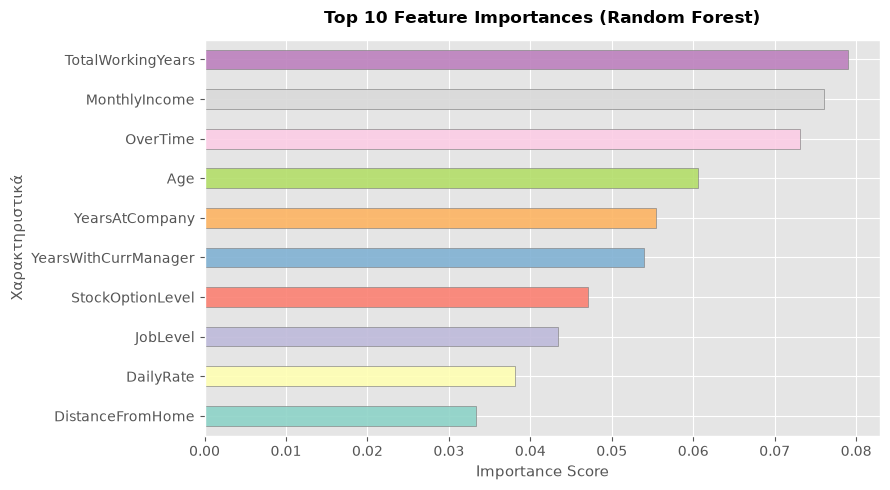

In [22]:
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10_features = feat_importances.sort_values(ascending=True).tail(10)

colors = [cmap(i) for i in range(len(top_10_features))]

plt.figure(figsize=(9, 5))
top_10_features.plot(kind='barh', color=colors, edgecolor='gray', alpha=0.9)
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Χαρακτηριστικά', fontsize=11)
plt.tight_layout()
plt.show()

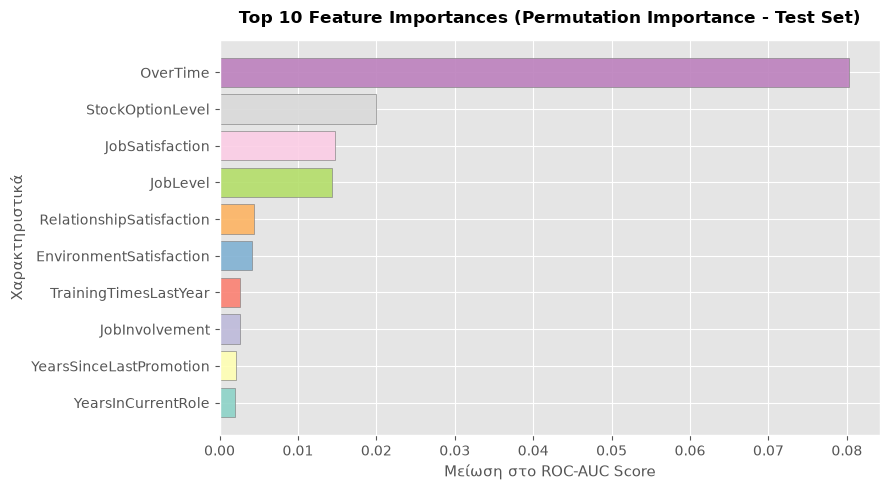

In [23]:
# Permutation Importance 
result = permutation_importance(
    rf_model, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='roc_auc'
)

sorted_idx = result.importances_mean.argsort()[-10:]
top_10_names = X_test.columns[sorted_idx]
top_10_values = result.importances_mean[sorted_idx]

colors = [cmap(i) for i in range(10)]

plt.figure(figsize=(9, 5))
plt.barh(top_10_names, top_10_values, color=colors, edgecolor='gray', alpha=0.9)
plt.title('Top 10 Feature Importances (Permutation Importance - Test Set)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Μείωση στο ROC-AUC Score', fontsize=11)
plt.ylabel('Χαρακτηριστικά', fontsize=11)
plt.tight_layout()
plt.show()


#### 1. Τι δείχνει
* Παίρνει τα άγνωστα δεδομένα δοκιμής (**Test Set**).
* **Ανακατεύει τυχαία scramble** τις τιμές μίας μόνο στήλης (π.χ. ανακατεύει ποιοι κάνουν υπερωρίες και ποιοι όχι), διατηρώντας όλες τις άλλες στήλες ίδιες.
* Μετράει **πόσο έπεσε η απόδοση του μοντέλου** στο ROC-AUC score.
---

#### 2. Επιχειρησιακή Ερμηνεία (HR Insights)

* **OverTime:** 
  * Αν αφαιρέσουμε την πληροφορία των υπερωριών, το μοντέλο χάνει άμεσα το μεγαλύτερο μέρος της διαγνωστικής του ικανότητας. Οι υπερωρίες είναι ο νούμερο 1 καταλύτης παραίτησης.
* **StockOptionLevel & JobLevel:** 
  * Εργαζόμενοι χωρίς μετοχικά δικαιώματα (Stock Options = 0) ή κολλημένοι σε χαμηλό ιεραρχικό επίπεδο έχουν πολύ μεγαλύτερη τάση φυγής.
* **JobSatisfaction & EnvironmentSatisfaction:** 
  * Επιβεβαιώνεται ότι η ψυχολογική ικανοποίηση από τον ρόλο και το περιβάλλον είναι εξίσου κρίσιμη με τις αποδοχές.
* **YearsSinceLastPromotion & YearsInCurrentRole:** 
  * Επηρεάζουν αρνητικά όταν ένας υπάλληλος μένει για πολλά χρόνια στον ίδιο ρόλο χωρίς προαγωγή.

---

Σε αντίθεση με το απλό Feature Importance που κοιτάζει μόνο τι είδε το δέντρο κατά την εκπαίδευση, το **Permutation Importance στο Test Set** αποδεικνύει ποιοι παράγοντες έχουν **πραγματική προβλεπτική αξία** σε νέους, άγνωστους υπαλλήλους.

In [24]:
# Risk Score με Random Forest
all_probs = rf_model.predict_proba(X)[:, 1]

df_dashboard = df.copy()

df_dashboard['Attrition_Probability'] = np.round(all_probs, 4)
df_dashboard['Attrition_Risk_Score'] = np.round(all_probs * 100, 2) 

def risk_category(prob):
    if prob >= 0.60:
        return 'High Risk'
    elif prob >= 0.35:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_dashboard['Risk_Level'] = df_dashboard['Attrition_Probability'].apply(risk_category)

output_filename = 'hr_attrition_dashboard_data.csv'
df_dashboard.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"successfully created the file '{output_filename}' with {len(df_dashboard)} rows!")
print(df_dashboard[['Department', 'JobRole', 'Attrition_Probability', 'Risk_Level']].head())

successfully created the file 'hr_attrition_dashboard_data.csv' with 1470 rows!
               Department                JobRole  Attrition_Probability  \
0                   Sales        Sales Executive                 0.6719   
1  Research & Development     Research Scientist                 0.2505   
2  Research & Development  Laboratory Technician                 0.5827   
3  Research & Development     Research Scientist                 0.5475   
4  Research & Development  Laboratory Technician                 0.4617   

    Risk_Level  
0    High Risk  
1     Low Risk  
2  Medium Risk  
3  Medium Risk  
4  Medium Risk  
